In [125]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
import cartopy.crs as ccrs
import cmocean
import seaborn as sns
from scipy.stats import pearsonr 
from scipy.stats import shapiro 
from scipy.stats import linregress
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from OceanDataStore import OceanDataCatalog 
from nemo_cookbook import NEMODataTree  
from matplotlib.patches import Rectangle


In [126]:
url = 'https://psl.noaa.gov/thredds/dodsC/Datasets/noaa.oisst.v2.highres/sst.week.mean.nc'


In [127]:
ds = xr.open_dataset(url)


In [128]:
ds_clipped_old = ds.sel(lat = slice(0.0, 80.0), lon = slice(275.0, 360.0), time = slice('1990-01-01', '2024-12-31'))
ds_clipped = ds_clipped_old.assign_coords(lon=(ds_clipped_old.lon - 360.0))

In [129]:
ds_clipped

<xarray.Dataset> Size: 795MB
Dimensions:  (time: 1826, lat: 320, lon: 340)
Coordinates:
  * time     (time) datetime64[ns] 15kB 1990-01-07 1990-01-14 ... 2024-12-29
  * lat      (lat) float32 1kB 0.125 0.375 0.625 0.875 ... 79.38 79.62 79.88
  * lon      (lon) float32 1kB -84.88 -84.62 -84.38 ... -0.625 -0.375 -0.125
Data variables:
    sst      (time, lat, lon) float32 795MB ...
Attributes:
    Conventions:                     CF-1.5
    title:                           NOAA/NCEI 1/4 Degree Daily Optimum Inter...
    institution:                     NOAA/National Centers for Environmental ...
    source:                          NOAA/NCEI https://www.ncei.noaa.gov/data...
    References:                      https://www.psl.noaa.gov/data/gridded/da...
    dataset_title:                   NOAA Daily Optimum Interpolation Sea Sur...
    version:                         Version 2.1
    comment:                         Reynolds, et al.(2007) Daily High-Resolu...
    _NCProperties:                   version=2,netcdf=4.7.0,hdf5=1.10.5,
    DODS_EXTRA.Unlimited_Dimension:  time

In [130]:
point = ds_clipped.sel(lat = 20.0, lon = -40.0, method = 'nearest')['sst']

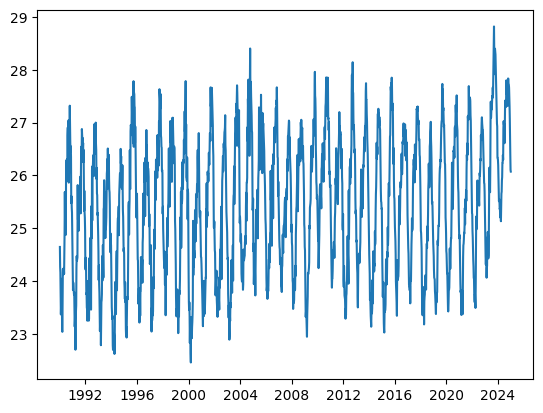

In [131]:
plt.plot(point['time'], point.values)

In [132]:
data = ds_clipped['sst'].sel(time = '1995-01-01', method = 'nearest')


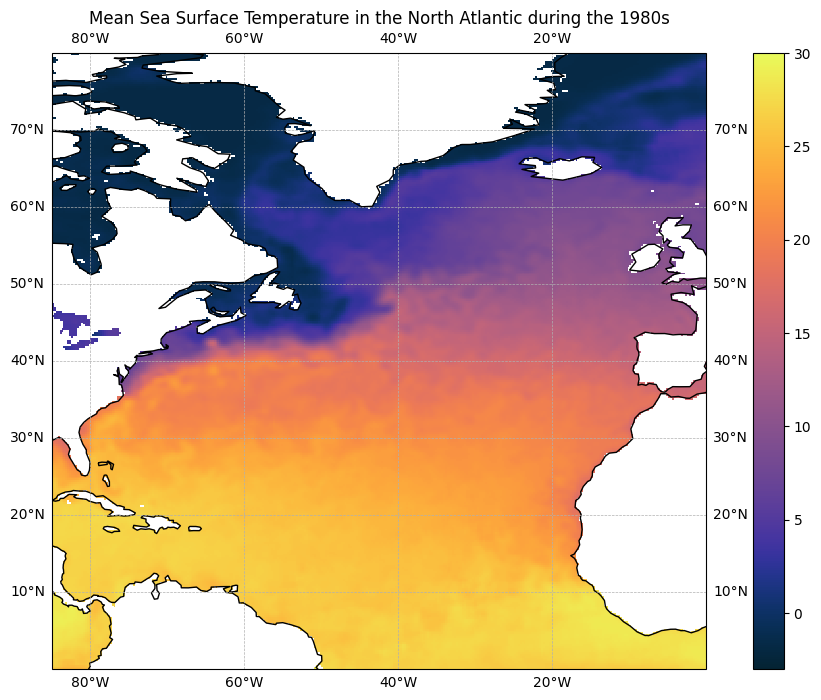

In [133]:
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

im = ax.pcolormesh(data['lon'],  data['lat'], data, cmap=cmocean.cm.thermal, transform=ccrs.PlateCarree(), vmin = -3, vmax = 30)
ax.coastlines()
ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
ax.set_title('Mean Sea Surface Temperature in the North Atlantic during the 1980s')

plt.colorbar(im, ax = ax)
plt.show()

In [136]:
land = data.sel(lat = 5.0, lon= -70.0, method = 'nearest')
land.values

array(nan, dtype=float32)

In [137]:
# Boolean mask of NaNs
nan_mask = ds_clipped["sst"].isnull()

# Count NaNs over time at each grid cell
nan_count = nan_mask.sum(dim="time")

# Total number of timesteps
nt = ds_clipped.sizes["time"]

# Grid cells where:
#   0 < nan_count < nt
partial_nan_mask = (nan_count > 0) & (nan_count < nt)

# Count how many such grid cells exist
n_partial = partial_nan_mask.sum().item()

print(f"Number of grid cells with partial NaNs: {n_partial}")

if n_partial > 0:
    print("There ARE grid cells with NaNs at some, but not all, timesteps.")
else:
    print("All grid cells are either completely NaN or completely valid.")

Number of grid cells with partial NaNs: 0
All grid cells are either completely NaN or completely valid.
